In [1]:
import numpy as np

kp1 = 2*10**3
km1 = 3*10**(-12)
kp2 = 2*10

XN = 0.01
XO = 0.01
XN2 = 0.75
XO2 = 0.23
XNO = 0

J = np.array([
    [-km1*XNO - kp2*XO2, kp1*XN2, kp1*XO, -kp2*XN, -km1*XN],
    [km1*XNO + kp2*XN2, -kp1*XN2, -kp1*XO, kp2*XN, km1*XN],
    [km1*XNO, -kp1*XN2, -kp1*XO, 0, km1*XN],
    [-kp2*XO2, 0, 0, -kp2*XN, 0],
    [-km1*XNO + kp2*XO2, kp1*XN2, kp1*XO, kp2*XN, -km1*XN]
])

eig_vals = np.linalg.eig(J)[0]

print(eig_vals)

eig_vals = abs(eig_vals)
print(eig_vals.max())
print(eig_vals.min())

[-1.53470546e+03  1.01066140e+01 -2.01151777e-01  9.29100551e-15
 -1.38788260e-30]
1534.7054622599937
1.3878826033409163e-30


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

kp1 = 2*10**3
km1 = 3*10**(-12)
kp2 = 2*10

XN_init = 0.01
XO_init = 0.01
XN2_init = 0.75
XO2_init = 0.23
XNO_init = 0

def dXNdt(XN_n, XO_n, XN2_n, XO2_n, XNO_n):
    return kp1*XN2_n*XO_n - km1*XNO_n*XN_n - kp2*XN_n*XO2_n
def dXOdt(XN_n, XO_n, XN2_n, XO2_n, XNO_n):
    return -kp1*XN2_n*XO_n + km1*XNO_n*XN_n + kp2*XN_n*XO2_n
def dXN2dt(XN_n, XO_n, XN2_n, XO2_n, XNO_n):
    return -kp1*XN2_n*XO_n + km1*XNO_n*XN_n
def dXO2dt(XN_n, XO_n, XN2_n, XO2_n, XNO_n):
    return -kp2*XN_n*XO2_n
def dXNOdt(XN_n, XO_n, XN2_n, XO2_n, XNO_n):
    return kp1*XN2_n*XO_n - km1*XNO_n*XN_n + kp2*XN_n*XO2_n

def rk4(t, dt):
    XN = XN_init * np.ones(t.shape)
    XO = XO_init * np.ones(t.shape)
    XN2 = XN2_init * np.ones(t.shape)
    XO2 = XO2_init * np.ones(t.shape)
    XNO = XNO_init * np.ones(t.shape)
    
    for n in range(len(t)-1):
        k1_XN = dXNdt(XN[n], XO[n], XN2[n], XO2[n], XNO[n])
        k1_XO = dXOdt(XN[n], XO[n], XN2[n], XO2[n], XNO[n])
        k1_XN2 = dXN2dt(XN[n], XO[n], XN2[n], XO2[n], XNO[n])
        k1_XO2 = dXO2dt(XN[n], XO[n], XN2[n], XO2[n], XNO[n])
        k1_XNO = dXNOdt(XN[n], XO[n], XN2[n], XO2[n], XNO[n])
        
        k2_XN = dXNdt(XN[n] + k1_XN*dt/2, XO[n] + k1_XO*dt/2, XN2[n] + k1_XN2*dt/2, XO2[n] + k1_XO2*dt/2, XNO[n] + k1_XNO*dt/2)
        k2_XO = dXOdt(XN[n] + k1_XN*dt/2, XO[n] + k1_XO*dt/2, XN2[n] + k1_XN2*dt/2, XO2[n] + k1_XO2*dt/2, XNO[n] + k1_XNO*dt/2)
        k2_XN2 = dXN2dt(XN[n] + k1_XN*dt/2, XO[n] + k1_XO*dt/2, XN2[n] + k1_XN2*dt/2, XO2[n] + k1_XO2*dt/2, XNO[n] + k1_XNO*dt/2)
        k2_XO2 = dXO2dt(XN[n] + k1_XN*dt/2, XO[n] + k1_XO*dt/2, XN2[n] + k1_XN2*dt/2, XO2[n] + k1_XO2*dt/2, XNO[n] + k1_XNO*dt/2)
        k2_XNO = dXNOdt(XN[n] + k1_XN*dt/2, XO[n] + k1_XO*dt/2, XN2[n] + k1_XN2*dt/2, XO2[n] + k1_XO2*dt/2, XNO[n] + k1_XNO*dt/2)
        
        k3_XN = dXNdt(XN[n] + k2_XN*dt/2, XO[n] + k2_XO*dt/2, XN2[n] + k2_XN2*dt/2, XO2[n] + k2_XO2*dt/2, XNO[n] + k2_XNO*dt/2)
        k3_XO = dXOdt(XN[n] + k2_XN*dt/2, XO[n] + k2_XO*dt/2, XN2[n] + k2_XN2*dt/2, XO2[n] + k2_XO2*dt/2, XNO[n] + k2_XNO*dt/2)
        k3_XN2 = dXN2dt(XN[n] + k2_XN*dt/2, XO[n] + k2_XO*dt/2, XN2[n] + k2_XN2*dt/2, XO2[n] + k2_XO2*dt/2, XNO[n] + k2_XNO*dt/2)
        k3_XO2 = dXO2dt(XN[n] + k2_XN*dt/2, XO[n] + k2_XO*dt/2, XN2[n] + k2_XN2*dt/2, XO2[n] + k2_XO2*dt/2, XNO[n] + k2_XNO*dt/2)
        k3_XNO = dXNOdt(XN[n] + k2_XN*dt/2, XO[n] + k2_XO*dt/2, XN2[n] + k2_XN2*dt/2, XO2[n] + k2_XO2*dt/2, XNO[n] + k2_XNO*dt/2)
        
        k4_XN = dXNdt(XN[n] + k3_XN*dt, XO[n] + k3_XO*dt, XN2[n] + k3_XN2*dt, XO2[n] + k3_XO2*dt, XNO[n] + k3_XNO*dt)
        k4_XO = dXOdt(XN[n] + k3_XN*dt, XO[n] + k3_XO*dt, XN2[n] + k3_XN2*dt, XO2[n] + k3_XO2*dt, XNO[n] + k3_XNO*dt)
        k4_XN2 = dXN2dt(XN[n] + k3_XN*dt, XO[n] + k3_XO*dt, XN2[n] + k3_XN2*dt, XO2[n] + k3_XO2*dt, XNO[n] + k3_XNO*dt)
        k4_XO2 = dXO2dt(XN[n] + k3_XN*dt, XO[n] + k3_XO*dt, XN2[n] + k3_XN2*dt, XO2[n] + k3_XO2*dt, XNO[n] + k3_XNO*dt)
        k4_XNO = dXNOdt(XN[n] + k3_XN*dt, XO[n] + k3_XO*dt, XN2[n] + k3_XN2*dt, XO2[n] + k3_XO2*dt, XNO[n] + k3_XNO*dt)
        
        XN[n+1] = XN[n] + (k1_XN + 2*k2_XN + 2*k3_XN + k4_XN)*dt/6
        XO[n+1] = XO[n] + (k1_XO + 2*k2_XO + 2*k3_XO + k4_XO)*dt/6
        XN2[n+1] = XN2[n] + (k1_XN2 + 2*k2_XN2 + 2*k3_XN2 + k4_XN2)*dt/6
        XO2[n+1] = XO2[n] + (k1_XO2 + 2*k2_XO2 + 2*k3_XO2 + k4_XO2)*dt/6
        XNO[n+1] = XNO[n] + (k1_XNO + 2*k2_XNO + 2*k3_XNO + k4_XNO)*dt/6
        
    return XN, XO, XN2, XO2, XNO

def jacobian(XN, XO, XN2, XO2, XNO):
    J = np.array([
        [-km1*XNO - kp2*XO2, kp1*XN2, kp1*XO, -kp2*XN, -km1*XN],
        [km1*XNO + kp2*XO2, -kp1*XN2, -kp1*XO, kp2*XN, km1*XN],
        [km1*XNO, -kp1*XN2, -kp1*XO, 0, km1*XN],
        [-kp2*XO2, 0, 0, -kp2*XN, 0],
        [-km1*XNO + kp2*XO2, kp1*XN2, kp1*XO, kp2*XN, -km1*XN]
    ])
    return J

def f(Xin):
    XN = Xin[0]
    XO = Xin[1]
    XN2 = Xin[2]
    XO2 = Xin[3]
    XNO = Xin[4]
    
    X = np.zeros(Xin.shape)
    X[0] = dXNdt(XN, XO, XN2, XO2, XNO)
    X[1] = dXOdt(XN, XO, XN2, XO2, XNO)
    X[2] = dXN2dt(XN, XO, XN2, XO2, XNO)
    X[3] = dXO2dt(XN, XO, XN2, XO2, XNO)
    X[4] = dXNOdt(XN, XO, XN2, XO2, XNO)
    
    return X

# Reference: https://shrenikm.com/posts/2021-09-25-implicit-euler-integration-using-newton-raphson/
def dirk2(t, dt):
    X = np.zeros((len(t),5))
    X[0,:] = [XN_init, XO_init, XN2_init, XO2_init, XNO_init]
    
    I = np.identity(5)
    
    for n in range(len(t)-1):
        
        J = jacobian(X[n,0], X[n,1], X[n,2], X[n,3], X[n,4])
        J_inv1 = np.linalg.inv(I - 1/3*dt*J)
        J_inv2 = np.linalg.inv(I - 1/4*dt*J)
        
        tol = 1e-5
        resid = 1
        
        X1_old = X[n,:].copy()
        while resid > tol:
            fX1 = f(X1_old)
            X1 = X1_old - J_inv1@(X1_old - X[n,:] - 1/3*dt*fX1)
            resid = np.max(abs(X1-X1_old))
            X1_old = X1
        
        fX1 = f(X1_old)
        resid = 1
            
        X2_old = X1.copy()
        while resid > tol:
            X2 = X2_old - J_inv2@(X2_old - X[n,:] - 3/4*dt*fX1 - 1/4*dt*f(X2_old))
            resid = np.max(abs(X2-X2_old))
            X2_old = X2
            
        fX2 = f(X2_old)
            
        X[n+1,:] = X[n,:] + dt*(3/4*fX1 + 1/4*fX2)
        
    return X

def bdf2(t, dt):
    X = np.zeros((len(t),5))
    X[0,:] = [XN_init, XO_init, XN2_init, XO2_init, XNO_init]
    X0 = X[0,:]
    
    I = np.identity(5)

    # USE BACKWARD EULER FOR FIRST STEP
    J = jacobian(XN_init, XO_init, XN2_init, XO2_init, XNO_init)
    J_inv = np.linalg.inv(I - dt*J)
    
    tol = 1e-5
    resid = 1
    
    X1_old = X0.copy()
    while resid > tol:
        fX1 = f(X1_old)
        X1 = X1_old - J_inv@(X1_old - X0 - dt*fX1)
        resid = np.max(abs(X1-X1_old))
        X1_old = X1
    X[1,:] = X1
    
    # USE BDF2 FOR FOLLOWING STEPS
    for n in range(1,len(t)-1):
        
        J = jacobian(X[n,0], X[n,1], X[n,2], X[n,3], X[n,4])
        J_inv = np.linalg.inv(I - 2/3*dt*J)
        
        resid = 1
        
        X1_old = X[n,:].copy()
        while resid > tol:
            fX1 = f(X1_old)
            X1 = X1_old - J_inv@(X1_old - 4/3*X[n,:] + 1/3*X[n-1,:] - 2/3*dt*fX1)
            resid = np.max(abs(X1-X1_old))
            X1_old = X1
        
        X[n+1,:] = X1
    
    return X

def dirk2_adaptive(tmin, tmax, dt0, maxiter):
    X = np.zeros((maxiter,5))
    t = np.zeros((maxiter,1))
    X[0,:] = [XN_init, XO_init, XN2_init, XO2_init, XNO_init]
    t[0] = tmin
    
    I = np.identity(5)
    
    dt = dt0
    n = 0
    
    while (t[n] < tmax and n < maxiter):
        
        J = jacobian(X[n,0], X[n,1], X[n,2], X[n,3], X[n,4])
        J_inv1 = np.linalg.inv(I - 1/3*dt*J)
        J_inv2 = np.linalg.inv(I - 1/4*dt*J)
        
        tol = 1e-5
        resid = 1
        
        '''
        # MULTIPLE NEWTON-RAPHSON ITERATIONS WITH FIXED INV JACOBIAN
        X1_old = X[n,:].copy()
        while resid > tol:
            fX1 = f(X1_old)
            X1 = X1_old - J_inv1@(X1_old - X[n,:] - 1/3*dt*fX1)
            resid = np.max(abs(X1-X1_old))
            X1_old = X1
        
        fX1 = f(X1_old)
        resid = 1
            
        X2_old = X1.copy()
        while resid > tol:
            X2 = X2_old - J_inv2@(X2_old - X[n,:] - 3/4*dt*fX1 - 1/4*dt*f(X2_old))
            resid = np.max(abs(X2-X2_old))
            X2_old = X2
            
        fX2 = f(X2_old)
        '''
        
        # ONLY ONE NEWTON-RAPHSON ITERATION
        X1_old = X[n,:].copy()
        fX1 = f(X1_old)
        X1 = X1_old - J_inv1@(X1_old - X[n,:] - 1/3*dt*fX1)
        
        fX1 = f(X1)
            
        X2_old = X1.copy()
        X2 = X2_old - J_inv2@(X2_old - X[n,:] - 3/4*dt*fX1 - 1/4*dt*f(X2_old))
            
        fX2 = f(X2)
            
        X[n+1,:] = X2
        t[n+1] = t[n] + dt
        
        epsilon = np.max(abs(X[n+1,:] - X[n,:])/abs(X[n,:]+1e-10))
        if epsilon < 0.1:
            dt = dt*1.1
            
        n += 1
    
    nfinal = n
        
    return t[:nfinal+1], X[:nfinal+1,:]

def bdf2_adaptive(tmin, tmax, dt0, maxiter):
    X = np.zeros((maxiter,5))
    t = np.zeros((maxiter,1))
    X[0,:] = [XN_init, XO_init, XN2_init, XO2_init, XNO_init]
    X0 = X[0,:]
    t[0] = tmin
    dt = dt0
    
    I = np.identity(5)
    
    # USE BACKWARD EULER FOR FIRST STEP
    J = jacobian(XN_init, XO_init, XN2_init, XO2_init, XNO_init)
    J_inv = np.linalg.inv(I - dt*J)
    
    X1_old = X0.copy()
    fX1 = f(X1_old)
    X1 = X1_old - J_inv@(X1_old - X0 - dt*fX1)
    X[1,:] = X1
        
    n = 1
    
    while (t[n] < tmax and n < maxiter):
    
        # USE BDF2 FOR FOLLOWING STEPS
        J = jacobian(X[n,0], X[n,1], X[n,2], X[n,3], X[n,4])
        J_inv = np.linalg.inv(I - 2/3*dt*J)
        
        X1_old = X[n,:].copy()
        fX1 = f(X1_old)
        X1 = X1_old - J_inv@(X1_old - 4/3*X[n,:] + 1/3*X[n-1,:] - 2/3*dt*fX1)
        
        X[n+1,:] = X1
        t[n+1] = t[n] + dt
        
        epsilon = np.max(abs(X[n+1,:] - X[n,:])/abs(X[n,:]+1e-12))
        if epsilon < 0.1:
            dt = dt*1.1
            
        n += 1
    
    nfinal = n
    
    return t[:nfinal+1], X[:nfinal+1,:]


Time: 3.4475293159484863


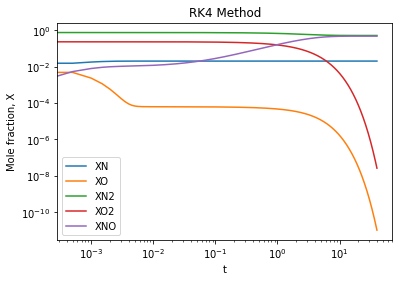

In [3]:
# APPLY RK4 METHOD
dt = 0.0005
t = np.arange(0,40,dt)

s = time.time()
XN, XO, XN2, XO2, XNO = rk4(t, dt)
runtime = time.time() - s
print('Time: ' + str(runtime))

# Plot results
plt.figure()
plt.loglog(t, XN, label='XN')
plt.loglog(t, XO, label='XO')
plt.loglog(t, XN2, label='XN2')
plt.loglog(t, XO2, label='XO2')
plt.loglog(t, XNO, label='XNO')
plt.legend()
plt.xlabel('t')
plt.ylabel('Mole fraction, X')
plt.title('RK4 Method')

plt.show()

Time: 6.13884973526001


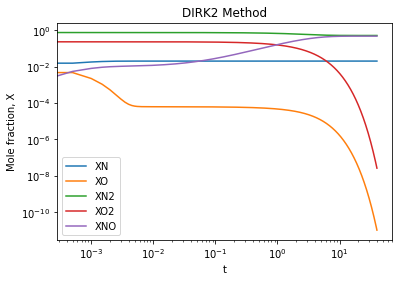

In [4]:
# APPLY DIRK2 METHOD
dt = 0.0005
t = np.arange(0,40,dt)

s = time.time()
X = dirk2(t, dt)
runtime = time.time() - s
print('Time: ' + str(runtime))

XN = X[:,0]
XO = X[:,1]
XN2 = X[:,2]
XO2 = X[:,3]
XNO = X[:,4]

# Plot results
plt.figure()
plt.loglog(t, XN, label='XN')
plt.loglog(t, XO, label='XO')
plt.loglog(t, XN2, label='XN2')
plt.loglog(t, XO2, label='XO2')
plt.loglog(t, XNO, label='XNO')
plt.legend()
plt.xlabel('t')
plt.ylabel('Mole fraction, X')
plt.title('DIRK2 Method')

plt.show()

Time: 3.281538724899292


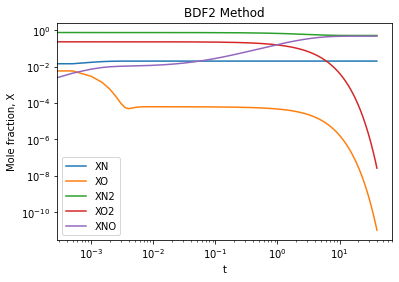

In [5]:
# APPLY BDF2 METHOD
dt = 0.0005
t = np.arange(0,40,dt)

s = time.time()
X = bdf2(t, dt)
runtime = time.time() - s
print('Time: ' + str(runtime))

XN = X[:,0]
XO = X[:,1]
XN2 = X[:,2]
XO2 = X[:,3]
XNO = X[:,4]

# Plot results
plt.figure()
plt.loglog(t, XN, label='XN')
plt.loglog(t, XO, label='XO')
plt.loglog(t, XN2, label='XN2')
plt.loglog(t, XO2, label='XO2')
plt.loglog(t, XNO, label='XNO')
plt.legend()
plt.xlabel('t')
plt.ylabel('Mole fraction, X')
plt.title('BDF2 Method')

plt.show()

Time: 0.019788742065429688


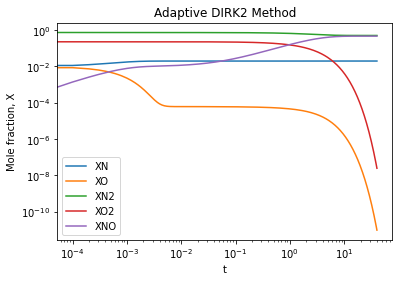

In [6]:
# APPLY ADAPTIVE DIRK2 METHOD
dt0 = 0.0001
maxiter = 80000

s = time.time()
t,X = dirk2_adaptive(0,40,dt0,maxiter)
runtime = time.time() - s
print('Time: ' + str(runtime))

XN = X[:,0]
XO = X[:,1]
XN2 = X[:,2]
XO2 = X[:,3]
XNO = X[:,4]

# Plot results
plt.figure()
plt.loglog(t, XN, label='XN')
plt.loglog(t, XO, label='XO')
plt.loglog(t, XN2, label='XN2')
plt.loglog(t, XO2, label='XO2')
plt.loglog(t, XNO, label='XNO')
plt.legend()
plt.xlabel('t')
plt.ylabel('Mole fraction, X')
plt.title('Adaptive DIRK2 Method')

plt.show()

Time: 0.014475107192993164


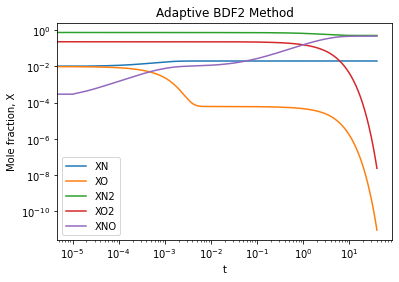

In [7]:
# APPLY ADAPTIVE BDF2 METHOD
dt0 = 0.00001
maxiter = 80000

s = time.time()
t,X = bdf2_adaptive(0,40,dt0,maxiter)
runtime = time.time() - s
print('Time: ' + str(runtime))

XN = X[:,0]
XO = X[:,1]
XN2 = X[:,2]
XO2 = X[:,3]
XNO = X[:,4]

# Plot results
plt.figure()
plt.loglog(t, XN, label='XN')
plt.loglog(t, XO, label='XO')
plt.loglog(t, XN2, label='XN2')
plt.loglog(t, XO2, label='XO2')
plt.loglog(t, XNO, label='XNO')
plt.legend()
plt.xlabel('t')
plt.ylabel('Mole fraction, X')
plt.title('Adaptive BDF2 Method')

plt.show()